### Regularization in ML and ANN: Theory and Mathematics

#### 1. **Theoretical Foundations**

**Regularization** is a set of techniques in machine learning and neural networks to **prevent overfitting** by discouraging complex models. Overfitting happens when a model fits the training data—including its noise—too closely, resulting in poor performance on unseen data.

Regularization achieves simplicity by modifying the loss function (the measure of model error) to **penalize large values** of model parameters (such as weights in ANNs).

#### 2. **Mathematical Formulation**

Let’s formalize the basic setup:

- **Original Loss Function:** $$ L $$
- **Weights:** $$ w $$
- **Regularization Parameter:** $$ \lambda $$ (controls penalty strength; higher = more regularization)
- **Regularized Loss:** $$ L' $$

##### **a) L2 Regularization (Ridge, Weight Decay):**

Adds a penalty proportional to the **squared weights**:

$$
L' = L + \frac{\lambda}{2} \sum_{i} w_i^2
$$

The updated gradient for weight updates during learning becomes:

$$
\frac{\partial L'}{\partial w_j} = \frac{\partial L}{\partial w_j} + \lambda w_j
$$

Thus, the weights update as:

$$
w_j \leftarrow w_j - \eta \left( \frac{\partial L}{\partial w_j} + \lambda w_j \right)
$$
or
$$
w_j \leftarrow (1 - \eta \lambda) w_j - \eta \frac{\partial L}{\partial w_j}
$$
Where:
- $$ \eta $$: Learning rate.
- The factor $$ (1 - \eta \lambda) $$ **shrinks** weights—hence the name "weight decay."

**Effect:** All weights are smoothly discouraged from growing large, but rarely go completely to zero.

##### **b) L1 Regularization (Lasso):**

Adds a penalty proportional to the **absolute values** of weights:

$$
L' = L + \lambda \sum_{i} |w_i|
$$

Gradient for L1 is non-smooth at zero, but most frameworks use **subgradients** for optimization:

$$
\frac{\partial |w_j|}{\partial w_j} = \begin{cases}
+1 & \text{if } w_j > 0 \\
-1 & \text{if } w_j < 0 \\
\text{undefined} & \text{if } w_j = 0
\end{cases}
$$

**Effect:** Tends to drive many weights **exactly to zero**—resulting in a sparse model, useful for feature selection.

##### **c) Elastic Net Regularization:**

Combines L1 and L2:

$$
L' = L + \lambda_1 \sum_{i} |w_i| + \frac{\lambda_2}{2} \sum_{i} w_i^2
$$

- **$$ \lambda_1 $$** controls L1 strength, **$$ \lambda_2 $$** controls L2 strength.
- Offers a trade-off between sparsity (L1) and smooth shrinkage (L2).

#### 3. **Interpretation and Effects**

- **Without Regularization:** The model minimizes only the loss $$ L $$, which can make weights arbitrarily large to fit the training data.
- **With Regularization:** The model must balance minimizing errors **and** keeping weights small.
    - Helps avoid memorizing noise (overfitting).
    - **Encourages generalization**: model works better on unseen data.
    - Helps in feature selection (especially with L1/Elastic Net).

#### 4. **General Algorithm for a Single Weight Update (with Regularization):**

Let $$ w_0 $$ be the current weight, $$ w_n $$ be the new weight,

$$
w_n = w_0 - \eta \left( \frac{\partial L}{\partial w_0} + \lambda w_0 \right)
$$

For **L2**, this can be rearranged to:
$$
w_n = (1 - \eta \lambda) w_0 - \eta \frac{\partial L}{\partial w_0}
$$
which shows explicit **multiplicative shrinking** (“decay”) of the weight vector.

#### 5. **Visual Summary**

- **L2:** Shrinks all weights toward zero.
- **L1:** Shrinks and zeros out some weights.
- **Elastic Net:** Shrinks and sparsifies, balancing L1 and L2.

#### 6. **Other Regularization Techniques (Briefly):**

- **Dropout:** Randomly deactivates neurons during training.
- **Early Stopping:** Halts training when validation error stops improving.
- **Data Augmentation:** Increases data diversity to avoid overfitting.

#### 7. **Why Is Regularization Important in ANN?**

- ANNs have many parameters—easily overfit with limited data.
- Regularization directly addresses this by *explicitly controlling the complexity* of the learned model.

**Summary:**  
Regularization alters the loss function to penalize complexity, most often by shrinking weights. This underpins the core strategy in both classic machine learning and deep neural networks for improving generalization, avoiding overfitting, and (in the case of L1 and Elastic Net) yielding simpler, sometimes sparse, models.

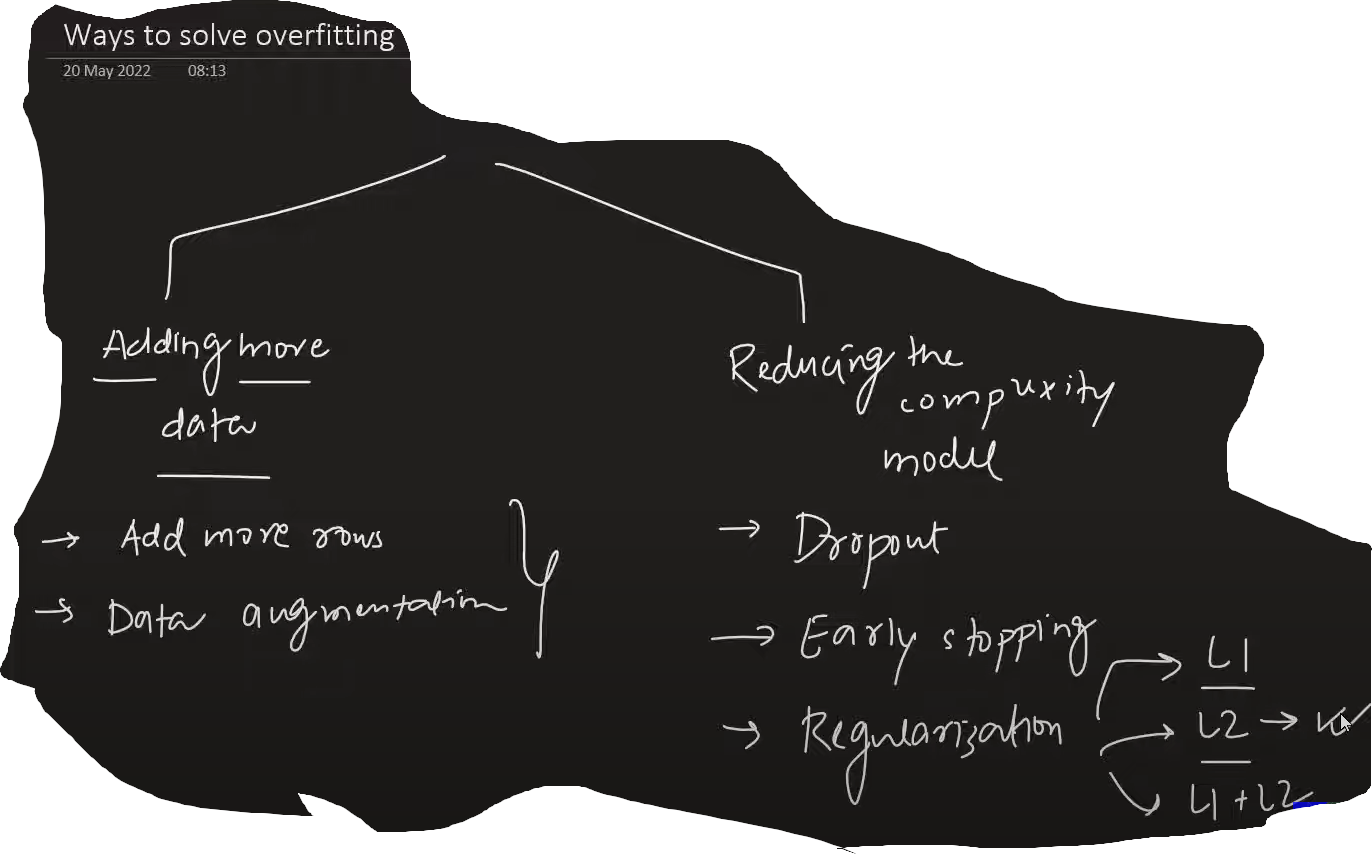

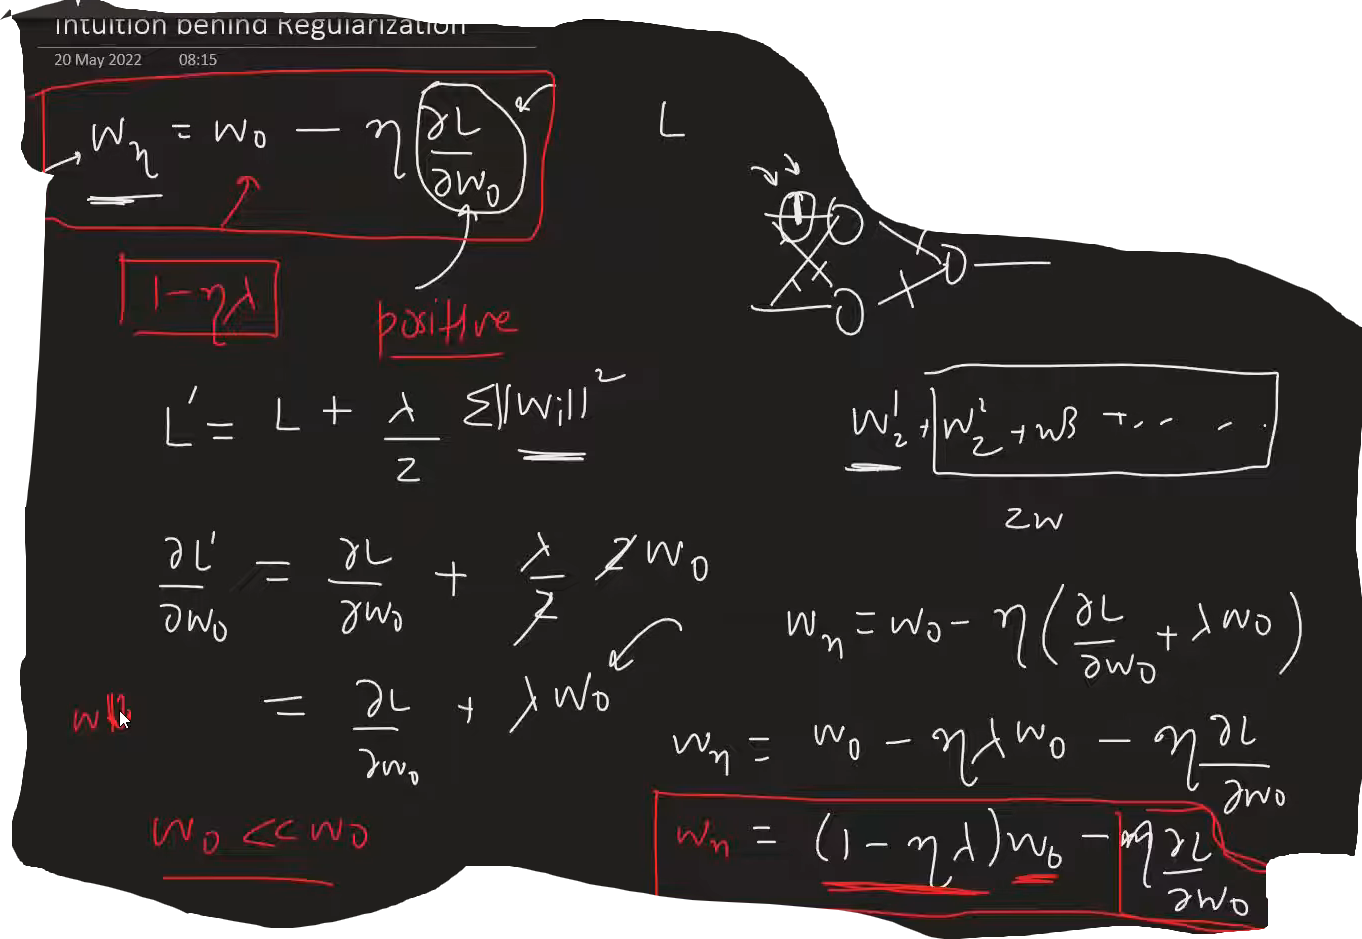


### **Key Sections and Equations**

#### 1. **Standard Weight Update in Gradient Descent**
   - Top-left red box:
     $$
     w_n = w_0 - \eta \frac{\partial L}{\partial w_0}
     $$
     - Here, $$w_n$$ is the new weight, $$w_0$$ is the current weight, $$\eta$$ is the learning rate, and $$L$$ is the loss.

#### 2. **Regularization Term**
   - **Modified Loss Function:**
     $$
     L' = L + \frac{\lambda}{2} \sum |w|^2
     $$
     - $$L'$$ is the regularized loss; $$\lambda$$ is the regularization parameter.

#### 3. **Gradient of the Regularized Loss**
   - $$
     \frac{\partial L'}{\partial w_0} = \frac{\partial L}{\partial w_0} + \lambda \sum 2 w_0\
     = \frac{\partial L}{\partial w_0} + \lambda w_0
     $$
     - The regularization adds a term proportional to the weight itself.

#### 4. **Update Rule for Regularized Loss**
   - $$
     w_n = w_0 - \eta \left(\frac{\partial L}{\partial w_0} + \lambda w_0\right)
     $$
     - This combines both the loss gradient and the regularization gradient.

#### 5. **Expanded Update Rule**
   - $$
     w_n = w_0 - \eta \lambda w_0 - \eta \frac{\partial L}{\partial w_0}
     $$
   - The formula inside the red box at the bottom:
     $$
     w_n = (1 - \eta \lambda) w_0 - \eta \frac{\partial L}{\partial w_0}
     $$

     - The coefficient $$(1 - \eta \lambda)$$ shrinks the weight each step, illustrating weight decay.

#### 6. **Conceptual Notes**
   - **Positive** label: Indicates that everything in the brackets is positive.
   - **$$1 - \eta \lambda$$**: Noted as a key shrinking factor.
   - **$$w_0 \ll w_0$$**: Emphasizes that weights shrink toward zero under regularization.
   - **$$w_n$$ equation**: Repeated to emphasize the shrinkage effect.

### **Diagrams**
- **Small diagram on the right:** A rough, abstract diagram, possibly showing classification boundaries or data points, for illustration.
- **Weights Squared block:** $$w_1^2 + w_2^2 + ...$$ under $$2 w$$, illustrating the sum in L2 regularization.

### **Color Coding**
- **Red:** Highlights key formulas, intuition points ("positive", "shrinking coefficients").
- **White:** Main working, derivations, and diagrams.

### **Summary**
- The image walks through the intuition and algebra behind L2 regularization ("weight decay"):
    - Regularization modifies the loss and hence the gradient.
    - This modification causes weights to shrink by a factor of $$(1 - \eta \lambda)$$ every update.
    - The result is smaller weights, which helps prevent overfitting.



also known as weight decay in NN {l2 norm}

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1, l2

# L1 (Lasso) Regularization Example
model_l1 = Sequential([
    Dense(32, input_dim=16, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(1, activation='sigmoid')
])

# L2 (Ridge/Weight Decay) Regularization Example
model_l2 = Sequential([
    Dense(32, input_dim=16, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#ElasticNet

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1_l2

# Elastic Net Regularization Example
model_elastic = Sequential([
    Dense(32, input_dim=16, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(1, activation='sigmoid')
])

